## **1. Setup libraries**

In [ ]:
import os 
import glob
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## **2. Load the spark pipeline output**

In [2]:
OUTPUT_DIR = "../output"

parquet_path = os.path.join(OUTPUT_DIR, "ml_air_quality.parquet")
csv_dir = os.path.join(OUTPUT_DIR, "ml_air_quality.csv")

if os.path.exists(csv_dir):
    csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {csv_dir}")
    df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    print(f"Loaded CSV: {df.shape}")
elif os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print(f"Loaded Parquet: {df.shape}")
else:
    raise FileNotFoundError(
        f"Could not find pipeline output in {OUTPUT_DIR}. "
        "Run `run_pipeline.py --steps etl features` first."
    )

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["station_name", "date"]).reset_index(drop=True)
df.head()

Loaded CSV: (2349095, 51)


,date,latitude,longitude,station_name,city,wind_speed_u,wind_speed_v,dewpoint_temp,soil_temp,total_percipitation,...,pm25_lag3,no2_lag1,no2_lag2,no2_lag3,o3_lag1,o3_lag2,o3_lag3,pm10_next_24h_mean,pm25_next_24h_mean,o3_next_24h_max
0,2020-05-01 00:00:00+00:00,37.988,23.728,ARISTOTELOUS,athens,1.945101,-1.013354,10.750844,18.336251,0.000041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.833333,34.625000,50.27482
1,2020-05-01 01:00:00+00:00,37.988,23.728,ARISTOTELOUS,athens,1.932266,-1.028591,10.732582,18.073293,0.000000,...,NaN,71.0,NaN,NaN,49.682840,NaN,NaN,49.541667,29.666667,50.27482
2,2020-05-01 02:00:00+00:00,37.988,23.728,ARISTOTELOUS,athens,1.952611,-1.090199,10.666181,17.808540,0.000000,...,NaN,55.0,71.0,NaN,49.415688,49.682840,NaN,43.333333,24.833333,25.00000
3,2020-05-01 03:00:00+00:00,37.988,23.728,ARISTOTELOUS,athens,1.938605,-1.169774,10.596040,17.542913,0.000000,...,131.0,48.0,55.0,71.0,50.274820,49.415688,49.682840,37.291667,20.958333,39.00000
4,2020-05-01 04:00:00+00:00,37.988,23.728,ARISTOTELOUS,athens,1.750025,-1.219598,10.583603,17.284210,0.000000,...,140.0,50.0,48.0,55.0,2.000000,50.274820,49.415688,34.000000,18.875000,51.00000


In [3]:
print(df.dtypes)

date                    datetime64[us, UTC]
latitude                            float64
longitude                           float64
station_name                            str
city                                    str
wind_speed_u                        float64
wind_speed_v                        float64
dewpoint_temp                       float64
soil_temp                           float64
total_percipitation                 float64
vegetation_high                     float64
vegetation_low                      float64
temp                                float64
relative_humidity                   float64
pm10                                float64
pm2_5                               float64
no2                                 float64
o3                                  float64
year                                  int64
month                                 int64
day                                   int64
hour                                  int64
day_of_week                     

In [4]:
print(f">> Stations: {df['station_name'].nunique()}")
print(f">> Date range: {df['date'].min()} -> {df['date'].max()}")
print(f">> Missing targets:\n{df[['pm10_next_24h_mean','pm25_next_24h_mean','o3_next_24h_max']].isna().sum()}")

>> Stations: 96
>> Date range: 2020-05-01 00:00:00+00:00 -> 2023-10-31 23:00:00+00:00
>> Missing targets:
pm10_next_24h_mean    96
pm25_next_24h_mean    96
o3_next_24h_max       96
dtype: int64


## **3. Choose Target and Feature Columns**

Matching `src/model/train.py`, exclude identifier/leak-prone columns and
the three target columns from the feature set. `city` and `season` are
categorical — we one-hot encode them here (PyTorch has no built-in
`StringIndexer` equivalent).

In [5]:
TARGET_COL = "o3_next_24h_max"

EXCLUDED_COLS = {
    "data", "station_name",
    "pm10_next_24h_mean", "pm25_next_24h_mean", "o3_next_24h_max",
}

df_model = df.dropna(subset=[TARGET_COL]).copy()
print(f">> Rows with non-null target '{TARGET_COL}': {len(df_model):,}")

categorical_cols = [c for c in ("city", "season") if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

feature_cols = [c for c in df_model.columns if c not in EXCLUDED_COLS]
print(f">> Feature count: {len(feature_cols)}")
feature_cols

>> Rows with non-null target 'o3_next_24h_max': 2,348,999
>> Feature count: 52


['date',
 'latitude',
 'longitude',
 'wind_speed_u',
 'wind_speed_v',
 'dewpoint_temp',
 'soil_temp',
 'total_percipitation',
 'vegetation_high',
 'vegetation_low',
 'temp',
 'relative_humidity',
 'pm10',
 'pm2_5',
 'no2',
 'o3',
 'year',
 'month',
 'day',
 'hour',
 'day_of_week',
 'is_weekend',
 'wind_speed',
 'wind_direction',
 'temp_dewpoint_spread',
 'temp_soil_diff',
 'pm10_pm25_ratio',
 'no2_o3_balance',
 'pm10_roll_24h_mean',
 'pm25_roll_24h_mean',
 'no2_roll_24h_mean',
 'o3_roll_24h_mean',
 'o3_roll_24h_max',
 'pm10_lag1',
 'pm10_lag2',
 'pm10_lag3',
 'pm25_lag1',
 'pm25_lag2',
 'pm25_lag3',
 'no2_lag1',
 'no2_lag2',
 'no2_lag3',
 'o3_lag1',
 'o3_lag2',
 'o3_lag3',
 'city_ancona',
 'city_athens',
 'city_zaragoza',
 'season_fall',
 'season_spring',
 'season_summer',
 'season_winter']

## **4. Build Sequence per Station**

In [6]:
SEQ_LEN = 24

# Start from rows that have the target
df_model = df.dropna(subset=[TARGET_COL]).copy()

# One-hot encode categoricals
categorical_cols = [c for c in ("city", "season") if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

feature_cols = [c for c in df_model.columns if c not in EXCLUDED_COLS]

# Clean bad numeric values before converting to arrays
df_model[feature_cols] = df_model[feature_cols].replace([np.inf, -np.inf], np.nan)

# Drop rows with any missing feature values or missing target
df_model = df_model.dropna(subset=feature_cols + [TARGET_COL]).copy().reset_index(drop=True)

print(f">> Clean rows: {len(df_model):,}")
print(f">> Feature count: {len(feature_cols)}")

# Build arrays after cleaning
X_all = df_model[feature_cols].to_numpy(dtype=np.float32, copy=True)
y_all = df_model[TARGET_COL].to_numpy(dtype=np.float32, copy=True)

print("Raw finite check:", np.isfinite(X_all).all(), np.isfinite(y_all).all())

# Build sequence start indices per station
start_idxs = []
for _, g in df_model.groupby("station_name", sort=False):
    pos = g.index.to_numpy()
    if len(pos) >= SEQ_LEN:
        start_idxs.extend(pos[: len(pos) - SEQ_LEN + 1])

start_idxs = np.asarray(start_idxs, dtype=np.int64)

print(f">> Total sequences: {len(start_idxs):,}")

# Train/val/test split on sequence starts
n = len(start_idxs)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_starts = start_idxs[:train_end]
val_starts = start_idxs[train_end:val_end]
test_starts = start_idxs[val_end:]

print(f"Train: {len(train_starts):,}  Val: {len(val_starts):,}  Test: {len(test_starts):,}")

# Fit scalers using only rows used by the training sequences
train_row_positions = np.unique(
    np.concatenate([np.arange(s, s + SEQ_LEN) for s in train_starts])
)

n_features = X_all.shape[1]

scaler_X = StandardScaler().fit(X_all[train_row_positions])
X_all_scaled = scaler_X.transform(X_all).astype(np.float32)

scaler_y = StandardScaler().fit(y_all[train_row_positions].reshape(-1, 1))
y_all_scaled = scaler_y.transform(y_all.reshape(-1, 1)).flatten().astype(np.float32)

print("Scaled finite check:", np.isfinite(X_all_scaled).all(), np.isfinite(y_all_scaled).all())

>> Clean rows: 2,339,190
>> Feature count: 52
Raw finite check: True True
>> Total sequences: 2,336,982
Train: 1,635,887  Val: 350,547  Test: 350,548
Scaled finite check: True True


In [7]:
# Clean feature columns before building arrays
df_model[feature_cols] = df_model[feature_cols].replace([np.inf, -np.inf], np.nan)

# Check which columns are dirty
bad_cols = df_model[feature_cols].columns[df_model[feature_cols].isna().any()]
print("Columns with missing values:")
print(df_model[bad_cols].isna().sum().sort_values(ascending=False).head(20))

# Safe fix: drop rows with missing features
df_model = df_model.dropna(subset=feature_cols + [TARGET_COL]).copy().reset_index(drop=True)

Columns with missing values:
Series([], dtype: float64)


## **5. Train/Val/Test Split & Scaling**

In [8]:
n = len(start_idxs)
train_end = int(n*0.70)
val_end = int(n*0.85)

train_starts = start_idxs[:train_end]
val_starts = start_idxs[train_end:val_end]
test_starts = start_idxs[val_end:]

print(f"Train: {len(train_starts):,}  Val: {len(val_starts):,}  Test: {len(test_starts):,}")

train_row_positions = np.unique(
    np.concatenate([np.arange(s, s + SEQ_LEN) for s in train_starts])
)

n_features = X_all.shape[1]
scaler_X = StandardScaler().fit(X_all[train_row_positions])
X_all_scaled = scaler_X.transform(X_all).astype(np.float32)

scaler_y = StandardScaler().fit(y_all[train_row_positions].reshape(-1, 1))
y_all_scaled = scaler_y.transform(y_all.reshape(-1, 1)).flatten().astype(np.float32)

Train: 1,635,887  Val: 350,547  Test: 350,548


In [9]:
print(np.isfinite(X_all).all(), np.isfinite(y_all).all())
print(np.isfinite(X_all_scaled).all(), np.isfinite(y_all_scaled).all())

True True
True True


## **6. PyTorch Dataset and DataLoaders**

In [10]:
class SequenceDataset(Dataset):
    def __init__(self, X, y, start_idxs, seq_len):
        self.X = X
        self.y = y
        self.start_idxs = start_idxs
        self.seq_len = seq_len

    def __len__(self):
        return len(self.start_idxs)
    

    def __getitem__(self, i):
        s = self.start_idxs[i]
        x = self.X[s : s + self.seq_len]
        y = self.y[s + self.seq_len - 1]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)
    
BATCH_SIZE = 256

train_ds = SequenceDataset(X_all_scaled, y_all_scaled, train_starts, SEQ_LEN)
val_ds = SequenceDataset(X_all_scaled, y_all_scaled, val_starts, SEQ_LEN)
test_ds = SequenceDataset(X_all_scaled, y_all_scaled, test_starts, SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches per epoch -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches per epoch -> train: 6391, val: 1370, test: 1370


## **7. Model 1 : LSTM Regressor**

A 2-layer LSTM reads the `(seq_len, n_features)` window and uses the final hidden state to predict the scalar target through a small MLP head.

In [11]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        out, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        return self.head(last_hidden).squeeze(-1)
    
lstm_model = LSTMRegressor(n_features=n_features).to(device)
print(lstm_model)
print(f">> Trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

LSTMRegressor(
  (lstm): LSTM(52, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
>> Trainable parameters: 65,601


## **8. Model 2 : 1D-CNN Regressor**

The same `(seq_len, n_features)` window, but treated as a 1D signal:

- `Conv1d` expects `(batch, channels, length)`, so `n_features` becomes the
channel dimension and `seq_len` the spatial dimension. 

- Stacked convolutions pooling extract local temporal patterns before a dense head.


In [12]:
class CNN1DRegressor(nn.Module):
    def __init__(self, n_features, seq_len, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1),  # global average pool over time -> (batch, 128, 1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x comes in as (batch, seq_len, n_features) -> transpose to (batch, n_features, seq_len)
        x = x.transpose(1, 2)
        x = self.conv(x)
        return self.head(x).squeeze(-1)


cnn_model = CNN1DRegressor(n_features=n_features, seq_len=SEQ_LEN).to(device)
print(cnn_model)
print(f"Trainable params: {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}")


CNN1DRegressor(
  (conv): Sequential(
    (0): Conv1d(52, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable params: 39,297


## **9. Shared Training Loop**

Both models shared the same training/ validation loop: MSE loss, Adam optimizer, early stopping on validation loss.

In [13]:
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, patience=5, name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                val_losses.append(criterion(preds, y_batch).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{name}] Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    return model, history


> **LSTM**

In [14]:
print(np.isfinite(X_all_scaled).all())
print(np.isfinite(y_all_scaled).all())


True
True


In [15]:
lstm_model, lstm_history = train_model(
    lstm_model, train_loader, val_loader, epochs=30, lr=1e-3, patience=5, name="LSTM"
)

[LSTM] Epoch 01 | train_loss=0.1437 | val_loss=0.1255
[LSTM] Epoch 02 | train_loss=0.0932 | val_loss=0.1041
[LSTM] Epoch 03 | train_loss=0.0769 | val_loss=0.0936
[LSTM] Epoch 04 | train_loss=0.0686 | val_loss=0.0878
[LSTM] Epoch 05 | train_loss=0.0633 | val_loss=0.0843
[LSTM] Epoch 06 | train_loss=0.0598 | val_loss=0.0845
[LSTM] Epoch 07 | train_loss=0.0571 | val_loss=0.0845
[LSTM] Epoch 08 | train_loss=0.0548 | val_loss=0.0780
[LSTM] Epoch 09 | train_loss=0.0529 | val_loss=0.0788
[LSTM] Epoch 10 | train_loss=0.0517 | val_loss=0.0767
[LSTM] Epoch 11 | train_loss=0.0505 | val_loss=0.0764
[LSTM] Epoch 12 | train_loss=0.0494 | val_loss=0.0770
[LSTM] Epoch 13 | train_loss=0.0484 | val_loss=0.0773
[LSTM] Epoch 14 | train_loss=0.0477 | val_loss=0.0747
[LSTM] Epoch 15 | train_loss=0.0471 | val_loss=0.0747
[LSTM] Epoch 16 | train_loss=0.0473 | val_loss=0.0727
[LSTM] Epoch 17 | train_loss=0.0463 | val_loss=0.0734
[LSTM] Epoch 18 | train_loss=0.0461 | val_loss=0.0731
[LSTM] Epoch 19 | train_loss

> 1D - CNN

In [ ]:
cnn_model, cnn_history = train_model(
    cnn_model, train_loader, val_loader, epochs=30, lr=1e-3, patience=5, name="CNN"
)

[CNN] Epoch 01 | train_loss=0.1577 | val_loss=0.1384
[CNN] Epoch 02 | train_loss=0.1098 | val_loss=0.1251
[CNN] Epoch 03 | train_loss=0.0971 | val_loss=0.1084


## **10. Vislualization Comparison**

Train loss and Validation loss are visualized how the loss drop.

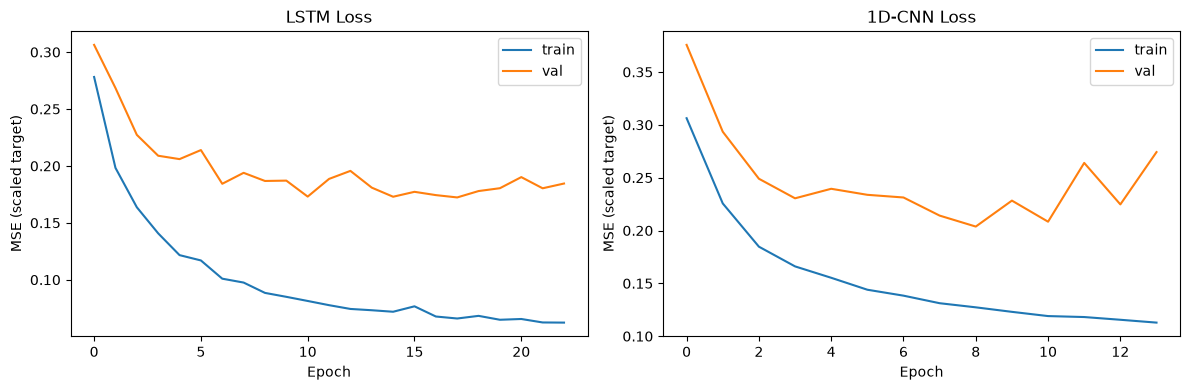

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lstm_history["train_loss"], label="train")
axes[0].plot(lstm_history["val_loss"], label="val")
axes[0].set_title("LSTM Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (scaled target)")
axes[0].legend()

axes[1].plot(cnn_history["train_loss"], label="train")
axes[1].plot(cnn_history["val_loss"], label="val")
axes[1].set_title("1D-CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE (scaled target)")
axes[1].legend()

plt.tight_layout()
plt.show()


## **11. Evaluation Model**

In [ ]:
def evaluate(model, loader, scaler_y):
    model.eval()
    preds_all, y_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            preds_all.append(preds)
            y_all.append(y_batch.numpy())

    preds_all = np.concatenate(preds_all).reshape(-1, 1)
    y_all = np.concatenate(y_all).reshape(-1, 1)

    preds_orig = scaler_y.inverse_transform(preds_all).flatten()
    y_orig = scaler_y.inverse_transform(y_all).flatten()

    rmse = mean_squared_error(y_orig, preds_orig) ** 0.5
    r2 = r2_score(y_orig, preds_orig)
    return rmse, r2, preds_orig, y_orig


lstm_rmse, lstm_r2, lstm_preds, y_test_orig = evaluate(lstm_model, test_loader, scaler_y)
cnn_rmse, cnn_r2, cnn_preds, _ = evaluate(cnn_model, test_loader, scaler_y)

print(f"Target: {TARGET_COL}")
print(f"{'Model':<12} {'RMSE':>10} {'R2':>10}")
print(f"{'LSTM':<12} {lstm_rmse:>10.4f} {lstm_r2:>10.4f}")
print(f"{'1D-CNN':<12} {cnn_rmse:>10.4f} {cnn_r2:>10.4f}")
print()
print("Compare these against the GBT baseline RMSE/R2 printed by `src/model/train.py`")
print("(also saved to output/metrics.txt by the Spark pipeline).")


Target: pm25_next_24h_mean
Model              RMSE         R2
LSTM             4.4072     0.8301
1D-CNN           4.5648     0.8178

Compare these against the GBT baseline RMSE/R2 printed by `src/model/train.py`
(also saved to output/metrics.txt by the Spark pipeline).


## **12. Saved Model**

In [ ]:
output_dir = "../output/saved_model"
os.makedirs(output_dir, exist_ok=True)

torch.save(lstm_model.state_dict(), os.path.join(output_dir, f"lstm_{TARGET_COL}.pt"))
torch.save(cnn_model.state_dict(), os.path.join(output_dir, f"cnn1d_{TARGET_COL}.pt"))

import joblib
joblib.dump(scaler_X, os.path.join(output_dir, f"scaler_X_{TARGET_COL}.joblib"))
joblib.dump(scaler_y, os.path.join(output_dir, f"scaler_y_{TARGET_COL}.joblib"))

print(f"Saved LSTM, 1D-CNN, and scalers for target '{TARGET_COL}' to {output_dir}/")


Saved LSTM, 1D-CNN, and scalers for target 'pm25_next_24h_mean' to ../output/saved_model/


`Note` : Target set for `"pm10_next_24h_mean", "pm25_next_24h_mean", "o3_next_24h_max"`. Trained reapeatedly from cell **section 3. Choose Target and Feature Columns** by changing `TARGET_COL` value.